In [1]:
#!pip install mlxtend

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
#Loading the dataset
df = pd.read_csv('medical_clean_D212.csv')

In [4]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [5]:
#Checking for missing values
print(df.isnull().sum())

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [6]:
#Normalize strings
df = df.fillna("").astype(str)
df = df.apply(lambda col: col.str.strip().str.lower())

In [7]:
#Checking for missing values again
print(df.isnull().sum())

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [8]:
#Number of prescriptions per row
presc_count = df.replace('', pd.NA).notna().sum(axis=1)

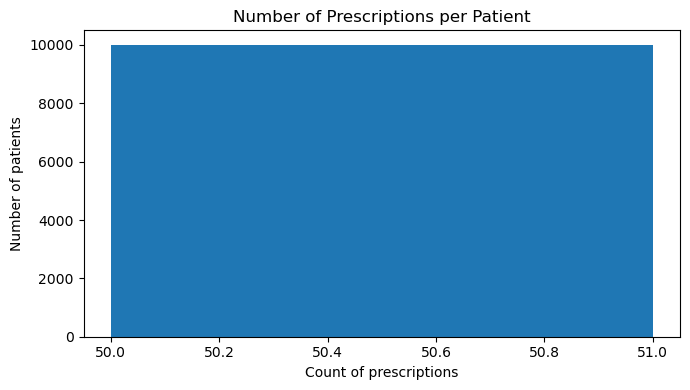

In [9]:
#Histogram
plt.figure(figsize=(7,4))
bins = range(int(presc_count.min()), int(presc_count.max())+2)
plt.hist(presc_count, bins=bins)
plt.title("Number of Prescriptions per Patient")
plt.xlabel("Count of prescriptions")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()

In [10]:
#Transforming data into transactional format
selected_cols = ["ReAdmis", 
                 "HighBlood",
                 "Stroke", 
                 "Overweight",
                 "Arthritis", 
                 "Diabetes", 
                 "Hyperlipidemia", 
                 "BackPain", 
                 "Anxiety", 
                 "Allergic_rhinitis", 
                 "Reflux_esophagitis",
                 "Asthma",
                 "Gender",
                 "Marital",
                 "Area"]
transactions = []
for _, row in df[selected_cols].iterrows():
    items = [str(v).lower() for v in row if v != ""]
    if items:
        transactions.append(sorted(set(items)))

print(f"\nTotal baskets (patients): {len(transactions)}")


Total baskets (patients): 10000


In [11]:
#One hot encoding
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("\nOne-hot encoded data preview:")
print(df_encoded.head())


One-hot encoded data preview:
   -100.02602  -100.0516  -100.0685  -100.06913  -100.1429  -100.14299  \
0       False      False      False       False      False       False   
1       False      False      False       False      False       False   
2       False      False      False       False      False       False   
3       False      False      False       False      False       False   
4       False      False      False       False      False       False   

   -100.18538  -100.1854  -100.1858  -100.2033  ...  zanesfield    zap  \
0       False      False      False      False  ...       False  False   
1       False      False      False      False  ...       False  False   
2       False      False      False      False  ...       False  False   
3       False      False      False      False  ...       False  False   
4       False      False      False      False  ...       False  False   

   zapata  zavala  zeigler  zelienople  zenda  zenia  ziebach  zumbro falls  
0

In [12]:
#Example of transaction
row_idx = 0  # or 1, 4, etc.
basket_from_ohe = df_encoded.columns[df_encoded.iloc[row_idx].astype(bool)].tolist()
print("Basket for row", row_idx, "from one-hot:", basket_from_ohe)

Basket for row 0 from one-hot: ['-86.72508', '0', '1', '10.58576971', '17939.40342', '19.1414657', '2', '2951', '3', '34.3496', '35621', '3726.70286', '3a83ddb66e2ae73798bdf1d705dc0932', '4', '53', '6', '86575.93', '8cd49b13-f45a-4b47-a2bd-173ffa932c2f', 'al', 'america/chicago', 'blood work', 'c412403', 'divorced', 'emergency admission', 'eva', 'male', 'medium', 'morgan', 'no', 'psychologist, sport and exercise', 'suburban', 'yes']


In [13]:
#Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True, max_len = 2, low_memory = True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print("\nFrequent itemsets:")
print(frequent_itemsets.head(10))

MemoryError: Unable to allocate 1015. MiB for an array with shape (8540, 124659) and data type bool

In [ ]:
#Association rules: support, confidencce, lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by=["lift","confidence","support"], ascending=False)

print("\nAssociation Rules (Top 10):")
print(rules[["antecedents","consequents","support","confidence","lift"]].head(10))

In [ ]:
#Top 3 rules
top3_rules = rules.head(3)
print("\nTop 3 Rules:")
print(top3_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

In [ ]:
#Saving data
new_data_path = 'output/new_medical_market_basket_D213_III.csv'
df.to_csv(new_data_path, index=False)

encoded_data_path = 'output/encoded_data_D213_III.csv'
df_encoded.to_csv(encoded_data_path, index=False)

frequent_items_path = 'output/frequent_items_D213_III.csv'
frequent_itemsets.to_csv(frequent_items_path, index=False)

rules_path = 'output/rules_D213_III.csv'
rules.to_csv(rules_path, index=False)

top3_rules_path = 'output/top3_rules_D213_III.csv'
top3_rules.to_csv(top3_rules_path, index=False)